In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


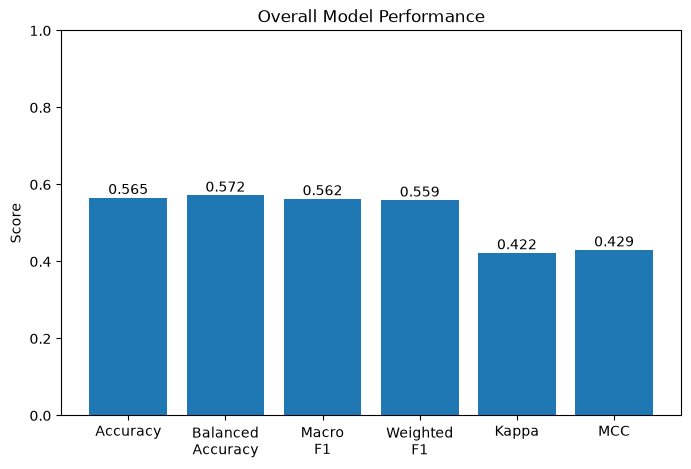

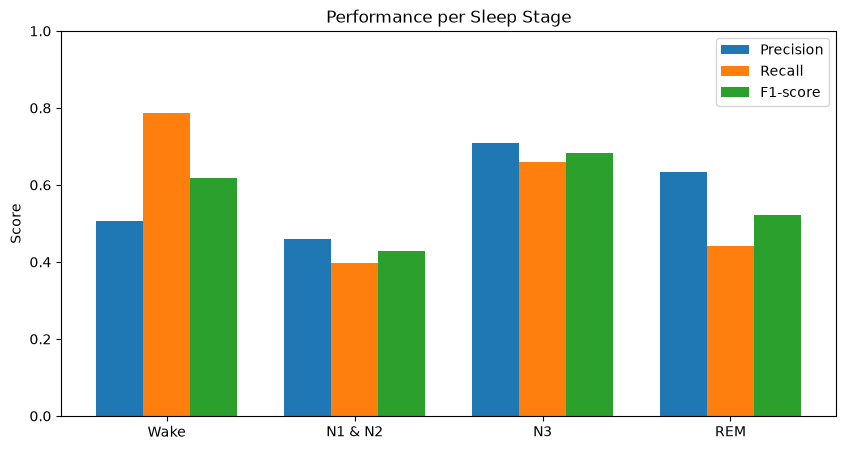

In [ ]:
metrics_path = Path("../outputs/metrics.json")

with open(metrics_path, "r") as f:
    metrics = json.load(f)

metrics

overall = {
    "Accuracy": metrics["accuracy"],
    "Balanced\nAccuracy": metrics["balanced_accuracy"],
    "Macro\nF1": metrics["f1_macro"],
    "Weighted\nF1": metrics["f1_weighted"],
    "Kappa": metrics["cohen_kappa"],
    "MCC": metrics["mcc"],
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    overall.keys(),
    overall.values()
)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Overall Model Performance")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.01,
        f"{y:.3f}",
        ha="center"
    )

plt.show()

classes = [
    "Wake",
    "N1 & N2",
    "N3",
    "REM"
]

precision = metrics["precision_per_class"]
recall = metrics["recall_per_class"]
f1 = metrics["f1_per_class"]

x = np.arange(len(classes))
w = 0.25

plt.figure(figsize=(10,5))

plt.bar(x-w, precision, width=w, label="Precision")
plt.bar(x, recall, width=w, label="Recall")
plt.bar(x+w, f1, width=w, label="F1-score")

plt.xticks(x, classes)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Performance per Sleep Stage")

plt.legend()

plt.show()

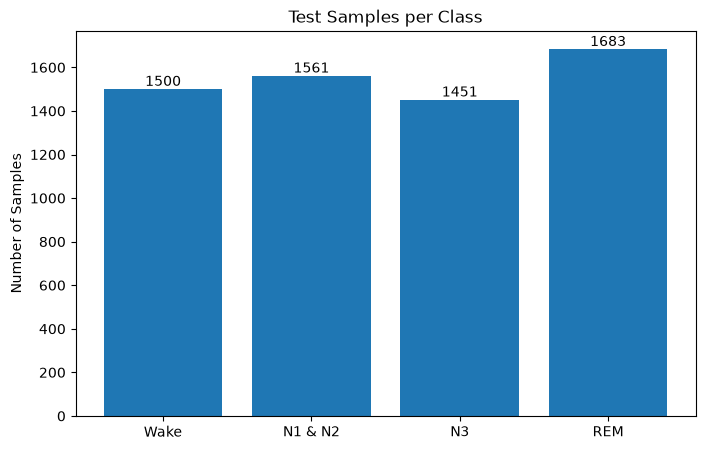

In [ ]:
support = metrics["support_per_class"]

plt.figure(figsize=(8,5))

bars = plt.bar(classes, support)

plt.ylabel("Number of Samples")

plt.title("Test Samples per Class")

for b in bars:
    y = b.get_height()
    plt.text(
        b.get_x()+b.get_width()/2,
        y,
        str(int(y)),
        ha="center",
        va="bottom"
    )

plt.show()

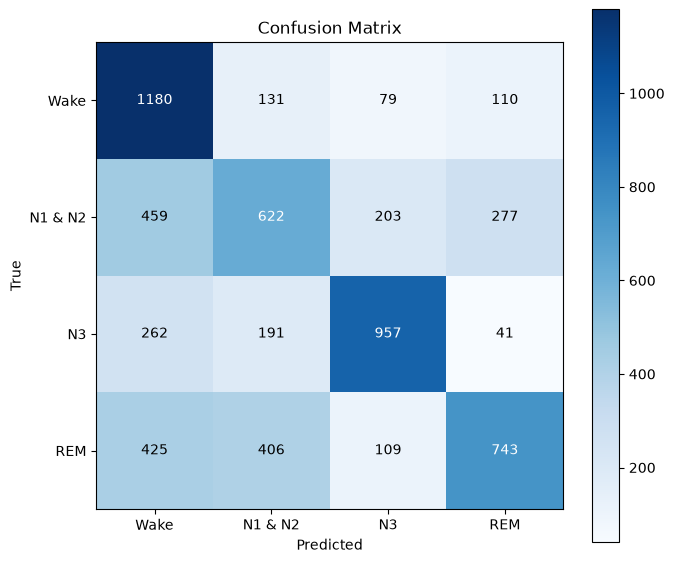

In [ ]:
cm = np.array(metrics["confusion_matrix"])

plt.figure(figsize=(7,6))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks(np.arange(len(classes)), classes)

plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i,j]),
            ha="center",
            va="center",
            color="white" if cm[i,j] > cm.max()/2 else "black"
        )

plt.tight_layout()

plt.show()